In [1]:
#Import Primary Modules:
import numpy as np  # useful for many scientific computing in Python
import pandas as pd # primary data structure library

# use the inline backend to generate the plots within the browser
%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use('ggplot')  # optional: for ggplot-like style

# check for latest version of Matplotlib
print('Matplotlib version: ', mpl.__version__) # >= 2.0.0

Matplotlib version:  3.10.7


In [5]:
df_can = pd.read_csv('survey_data.csv')

print('Data read into a pandas dataframe!')

Data read into a pandas dataframe!


In [6]:
df_can.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [14]:
print(df_can.columns.tolist())

['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith',

In [19]:
for col, dtype in df_can.dtypes.items():
    print(f"{col}: {dtype}")

ResponseId: int64
MainBranch: object
Age: object
Employment: object
RemoteWork: object
Check: object
CodingActivities: object
EdLevel: object
LearnCode: object
LearnCodeOnline: object
TechDoc: object
YearsCode: object
YearsCodePro: object
DevType: object
OrgSize: object
PurchaseInfluence: object
BuyNewTool: object
BuildvsBuy: object
TechEndorse: object
Country: object
Currency: object
CompTotal: float64
LanguageHaveWorkedWith: object
LanguageWantToWorkWith: object
LanguageAdmired: object
DatabaseHaveWorkedWith: object
DatabaseWantToWorkWith: object
DatabaseAdmired: object
PlatformHaveWorkedWith: object
PlatformWantToWorkWith: object
PlatformAdmired: object
WebframeHaveWorkedWith: object
WebframeWantToWorkWith: object
WebframeAdmired: object
EmbeddedHaveWorkedWith: object
EmbeddedWantToWorkWith: object
EmbeddedAdmired: object
MiscTechHaveWorkedWith: object
MiscTechWantToWorkWith: object
MiscTechAdmired: object
ToolsTechHaveWorkedWith: object
ToolsTechWantToWorkWith: object
ToolsTechAdmi

## Task 1

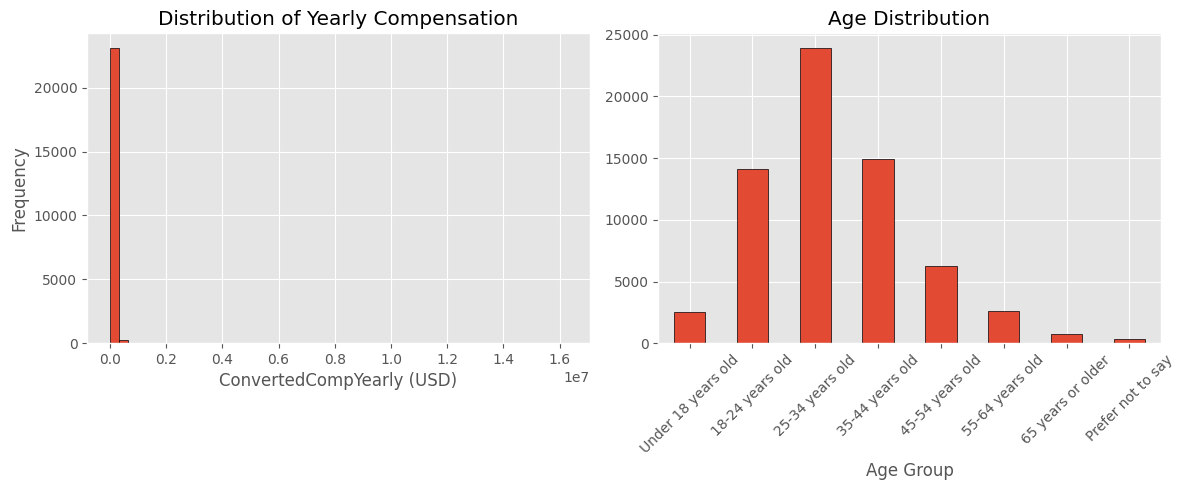

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram - Thu nhập
df_can['ConvertedCompYearly'].dropna().plot(kind='hist', bins=50, ax=axes[0], edgecolor='black')
axes[0].set_title('Distribution of Yearly Compensation')
axes[0].set_xlabel('ConvertedCompYearly (USD)')

# Box plot - Tuổi
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old', '35-44 years old', 
             '45-54 years old', '55-64 years old', '65 years or older', 'Prefer not to say']
df_can['Age'] = pd.Categorical(df_can['Age'], categories=age_order, ordered=True)
df_can['Age'].value_counts().sort_index().plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age Group')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Task 2

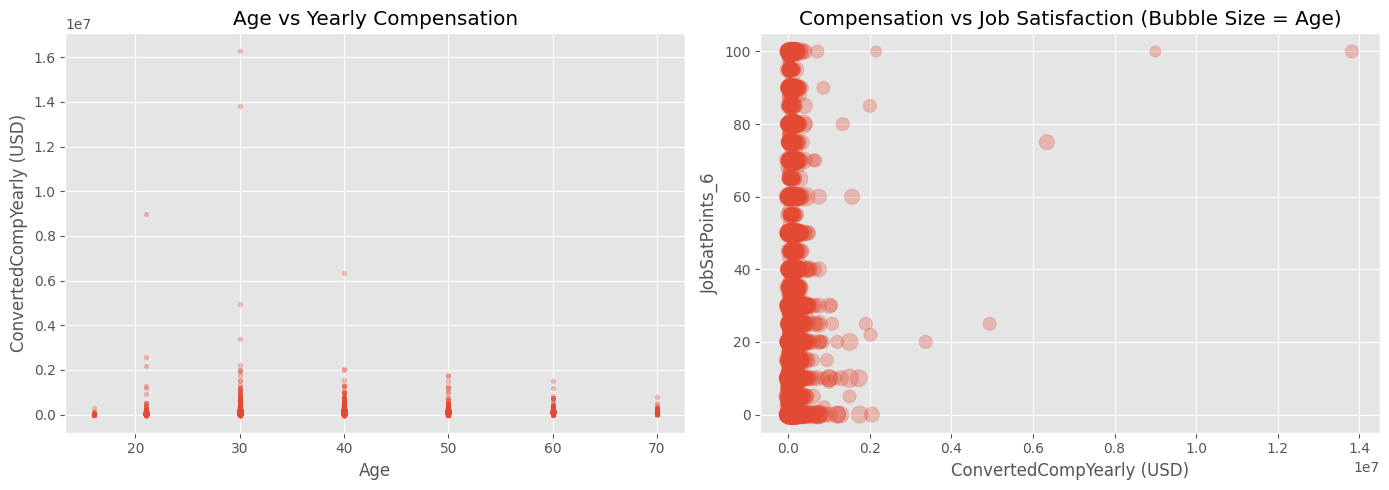

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 1. Scatter Plot: Age vs Compensation
axes[0].scatter(df_can['Age_Numeric'], df_can['ConvertedCompYearly'], alpha=0.3, s=10)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('ConvertedCompYearly (USD)')
axes[0].set_title('Age vs Yearly Compensation')
# 2. Bubble Plot: Compensation vs JobSat, size = Age
df_bubble = df_can[['ConvertedCompYearly', 'JobSatPoints_6', 'Age_Numeric']].dropna()
axes[1].scatter(df_bubble['ConvertedCompYearly'], df_bubble['JobSatPoints_6'], 
                s=df_bubble['Age_Numeric']*3, alpha=0.3)
axes[1].set_xlabel('ConvertedCompYearly (USD)')
axes[1].set_ylabel('JobSatPoints_6')
axes[1].set_title('Compensation vs Job Satisfaction (Bubble Size = Age)')
plt.tight_layout()
plt.show()

### Task 3

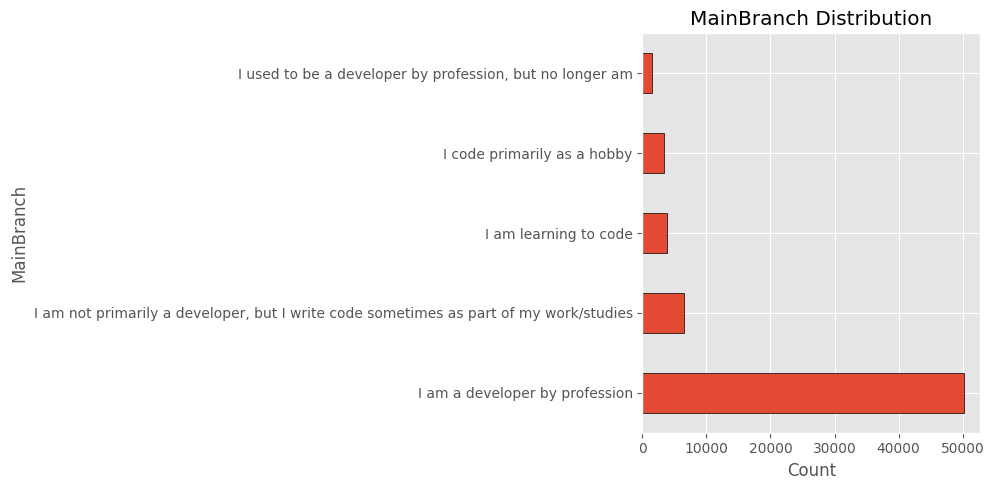

C:\Users\minhtq\AppData\Local\Temp\ipykernel_27152\3379778882.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  jobsat_by_age = df_can.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median().dropna()


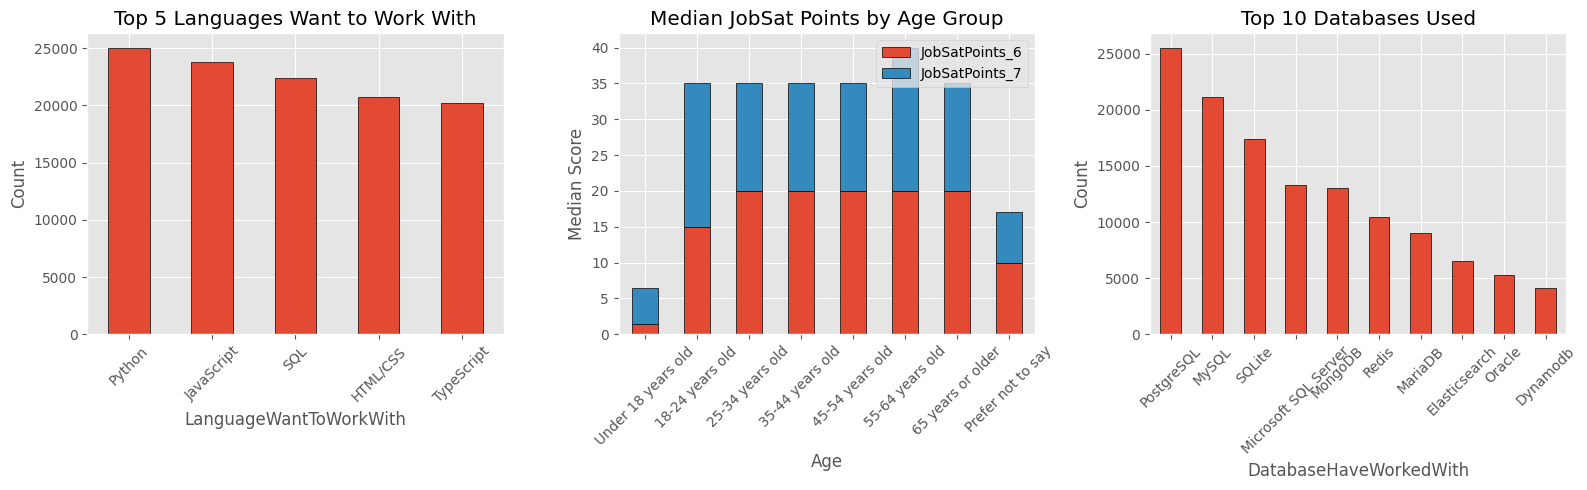

In [ ]:
# 1. Horizontal Bar - MainBranch Distribution (riêng)
plt.figure(figsize=(10, 5))
df_can['MainBranch'].value_counts().plot(kind='barh', edgecolor='black')
plt.title('MainBranch Distribution')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Top 5 Languages Want to Work With
lang_counts = df_can['LanguageWantToWorkWith'].dropna().str.split(';').explode().value_counts()
lang_counts.head(5).plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Top 5 Languages Want to Work With')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Stacked Bar - Median JobSat by Age Group
jobsat_by_age = df_can.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median().dropna()
jobsat_by_age.plot(kind='bar', stacked=True, ax=axes[1], edgecolor='black')
axes[1].set_title('Median JobSat Points by Age Group')
axes[1].set_ylabel('Median Score')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper right')

# Database Popularity
db_counts = df_can['DatabaseHaveWorkedWith'].dropna().str.split(';').explode().value_counts()
db_counts.head(10).plot(kind='bar', ax=axes[2], edgecolor='black')
axes[2].set_title('Top 10 Databases Used')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Task 4

C:\Users\minhtq\AppData\Local\Temp\ipykernel_27152\4250603746.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_comp = df_can.groupby('Age')['ConvertedCompYearly'].median().dropna().sort_index()


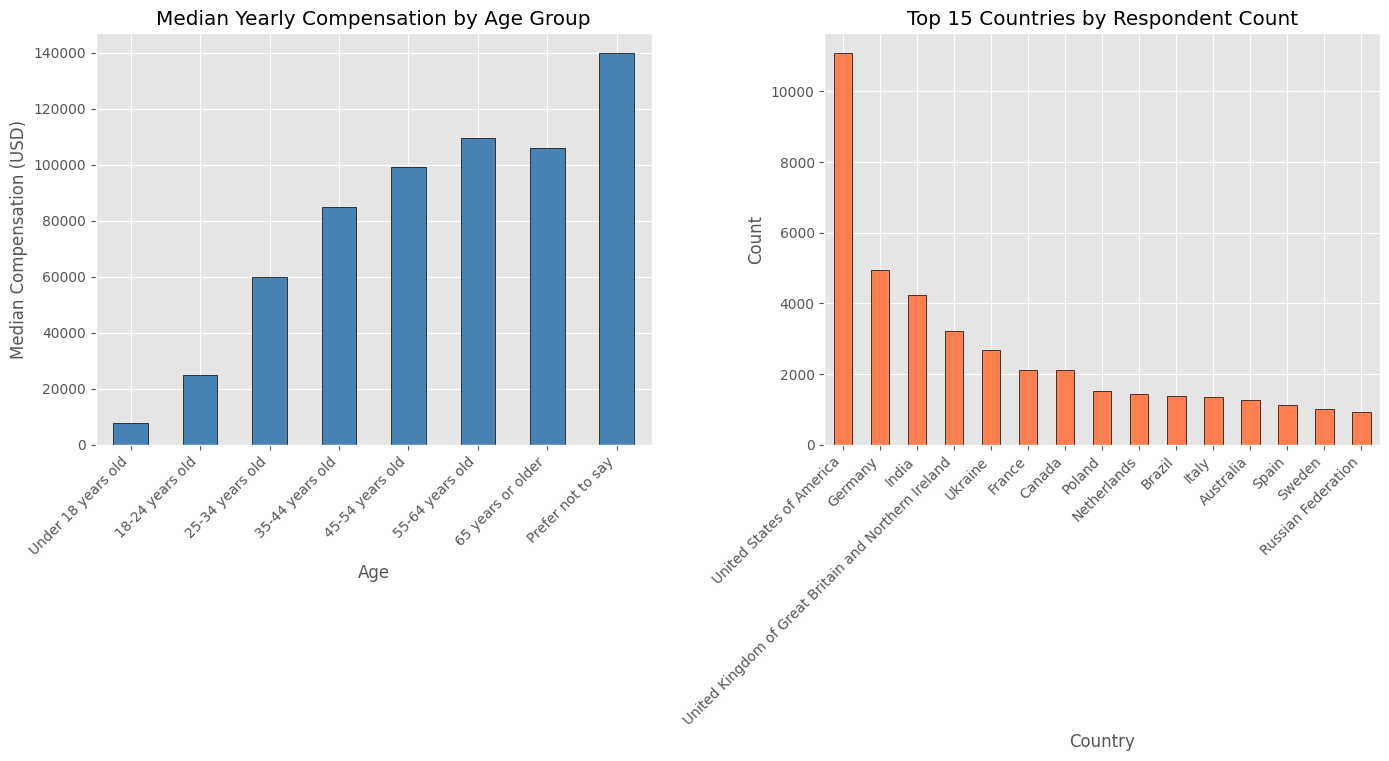

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Grouped Bar - Median Compensation by Age Group
median_comp = df_can.groupby('Age')['ConvertedCompYearly'].median().dropna().sort_index()
median_comp.plot(kind='bar', ax=axes[0], edgecolor='black', color='steelblue')
axes[0].set_title('Median Yearly Compensation by Age Group')
axes[0].set_ylabel('Median Compensation (USD)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# 2. Bar - Respondent Count by Country (Top 15)
country_counts = df_can['Country'].value_counts().head(15)
country_counts.plot(kind='bar', ax=axes[1], edgecolor='black', color='coral')
axes[1].set_title('Top 15 Countries by Respondent Count')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()